In [25]:
# ! git clone https://github.com/TrGiaHuy1710-valid/testChess

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [27]:
img_path = "test.png"
img = cv2.imread(img_path)

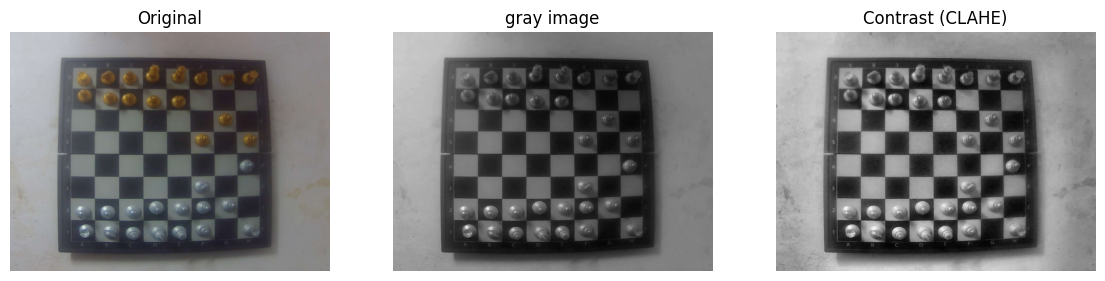

In [28]:
img = cv2.resize(img, (800, 600))

# =============================
# 2. Gray
# =============================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# =============================
# 3. Tăng tương phản (CLAHE)
# =============================
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
contrast = clahe.apply(gray)

plt.figure(figsize=(14,8))

# Original
plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

# Gray
plt.subplot(2,3,2)
plt.imshow(gray, cmap="gray")
plt.title("gray image")
plt.axis("off")

# CLAHE
plt.subplot(2,3,3)
plt.imshow(contrast, cmap="gray")
plt.title("Contrast (CLAHE)")
plt.axis("off")

plt.show()


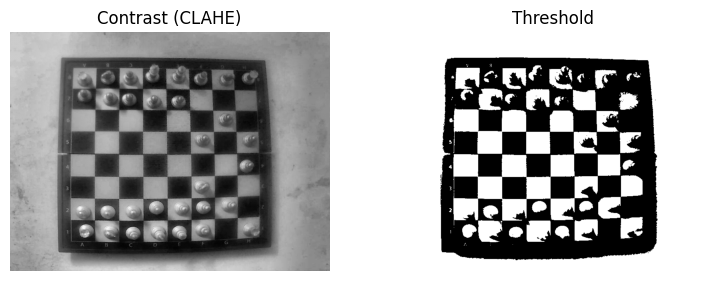

In [29]:
# =============================
# 5. Threshold (Otsu)
# =============================
_, thresh = cv2.threshold(
    contrast,
    0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

plt.figure(figsize=(14,8))

# CLAHE
plt.subplot(2,3,1)
plt.imshow(contrast, cmap="gray")
plt.title("Contrast (CLAHE)")
plt.axis("off")

# Threshold
plt.subplot(2,3,2)
plt.imshow(thresh, cmap="gray")
plt.title("Threshold")
plt.axis("off")

plt.show()



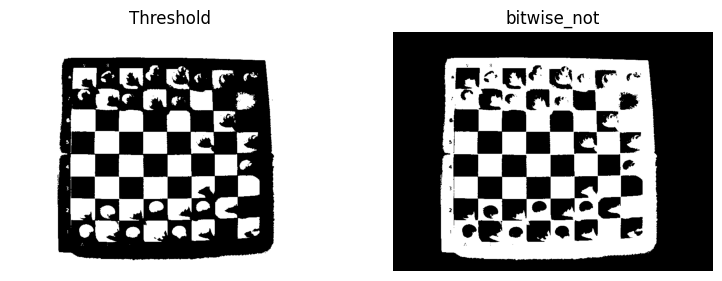

In [30]:
# Đảo ảnh (nếu cần)
thresh_bit = cv2.bitwise_not(thresh)

plt.figure(figsize=(14,8))

# Threshold
plt.subplot(2,3,1)
plt.imshow(thresh, cmap="gray")
plt.title("Threshold")
plt.axis("off")

# bitwise_not
plt.subplot(2,3,2)
plt.imshow(thresh_bit, cmap="gray")
plt.title("bitwise_not")
plt.axis("off")

plt.show()

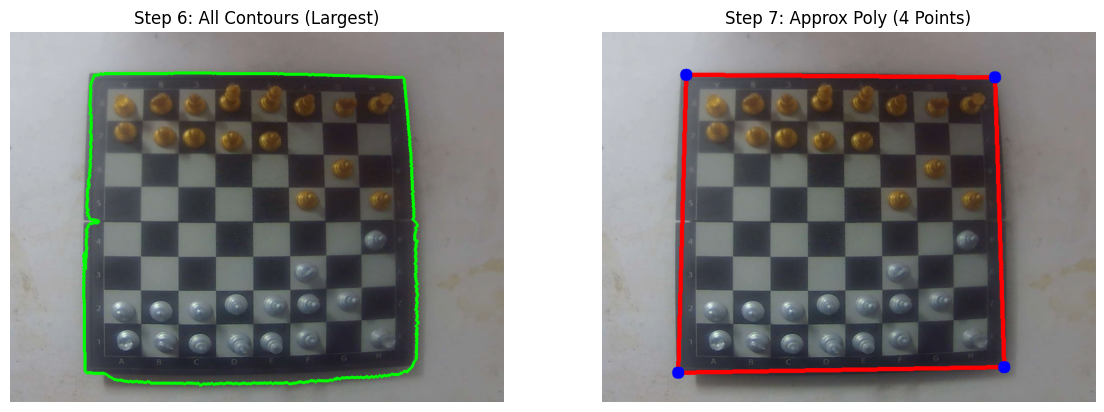

In [31]:
# --- STEP 6: PHÁT HIỆN ĐƯỜNG BAO (FINDING CONTOURS) ---
# Sử dụng RETR_EXTERNAL để chỉ lấy các đường bao ngoài cùng (khung bàn cờ)
contours, _ = cv2.findContours(thresh_bit, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Tạo một bản sao của ảnh gốc để vẽ kết quả lên đó (giả sử ảnh gốc là img_res)
img_contour = img.copy()
img_approx = img.copy()

board_contour = None

if contours:
    # --- STEP 7.1: LỌC DIỆN TÍCH (MAX AREA) ---
    # Tìm đường bao có diện tích lớn nhất trong danh sách
    largest_contour = max(contours, key=cv2.contourArea)

    # Chỉ xử lý nếu diện tích đủ lớn (tránh nhiễu nhỏ)
    if cv2.contourArea(largest_contour) > 5000:
        cv2.drawContours(img_contour, [largest_contour], -1, (0, 255, 0), 3)

        # --- STEP 7.2: XẤP XỈ ĐA GIÁC (APPROXPOLYDP) ---
        # Tính chu vi đường bao
        peri = cv2.arcLength(largest_contour, True)
        # Xấp xỉ đường bao thành các đoạn thẳng (sai số 2% chu vi)
        approx = cv2.approxPolyDP(largest_contour, 0.02 * peri, True)

        # Nếu đa giác có đúng 4 đỉnh, đó chính là bàn cờ
        if len(approx) == 4:
            board_contour = approx
            cv2.drawContours(img_approx, [approx], -1, (0, 0, 255), 5)
            # Đánh dấu các đỉnh tìm được
            for pt in approx:
                cv2.circle(img_approx, (pt[0][0], pt[0][1]), 10, (255, 0, 0), -1)

# --- HIỂN THỊ KẾT QUẢ ---
plt.figure(figsize=(14, 8))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_contour, cv2.COLOR_BGR2RGB))
plt.title("Step 6: All Contours (Largest)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_approx, cv2.COLOR_BGR2RGB))
plt.title("Step 7: Approx Poly (4 Points)")
plt.axis("off")

plt.show()

In [32]:
print(board_contour)

def calculate_optimal_side(board_contour, step=10):
    # 1. Định dạng lại tọa độ thành (4, 2)
    pts = board_contour.reshape(4, 2)
    
    # 2. Xác định các điểm (giả định theo thứ tự hoặc sắp xếp lại)
    # Ở đây ta tính độ dài 4 cạnh của tứ giác
    def dist(p1, p2):
        return np.sqrt(np.sum((p1 - p2)**2))

    # Cạnh trên, dưới, trái, phải
    side_top = dist(pts[0], pts[3])    # [136, 69] đến [636, 73]
    side_bottom = dist(pts[1], pts[2]) # [123, 552] đến [651, 543]
    side_left = dist(pts[0], pts[1])   # [136, 69] đến [123, 552]
    side_right = dist(pts[3], pts[2])  # [636, 73] đến [651, 543]

    # 3. Tính toán side mong muốn
    # Cách 1: Lấy giá trị lớn nhất để giữ nguyên độ phân giải tốt nhất
    side = int(max(side_top, side_bottom, side_left, side_right))
    
    # Cách 2 (Tùy chọn): Lấy trung bình cộng
    # side = int((side_top + side_bottom + side_left + side_right) / 4)


    side = int((side // step) * step)
    return side

WRAP_SIZE = calculate_optimal_side(board_contour)

print(f"Kích thước side tối ưu là: {WRAP_SIZE}")

[[[136  69]]

 [[123 552]]

 [[651 543]]

 [[636  73]]]
Kích thước side tối ưu là: 520


## Wrap perpective

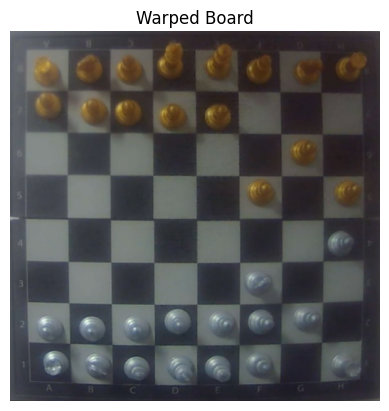

In [33]:
def order_points(pts):

    rect = np.zeros((4, 2), dtype="float32")
    s = pts.reshape(4, 2).sum(axis=1)
    rect[0] = pts.reshape(4, 2)[np.argmin(s)]
    rect[2] = pts.reshape(4, 2)[np.argmax(s)]
    diff = np.diff(pts.reshape(4, 2), axis=1)
    rect[1] = pts.reshape(4, 2)[np.argmin(diff)]
    rect[3] = pts.reshape(4, 2)[np.argmax(diff)]
    return rect

if board_contour is not None:
    # 1. Sắp xếp điểm và Warp
    pts_src = order_points(board_contour)
    side = WRAP_SIZE # Kích thước bàn cờ vuông muốn output
    pts_dst = np.array([
        [0, 0], [side - 1, 0],
        [side - 1, side - 1], [0, side - 1]
    ], dtype="float32")

    M = cv2.getPerspectiveTransform(pts_src, pts_dst)
    warped = cv2.warpPerspective(img, M, (side, side))

    plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    plt.title("Warped Board")
    plt.axis("off")
    plt.show()

(520, 520, 3)


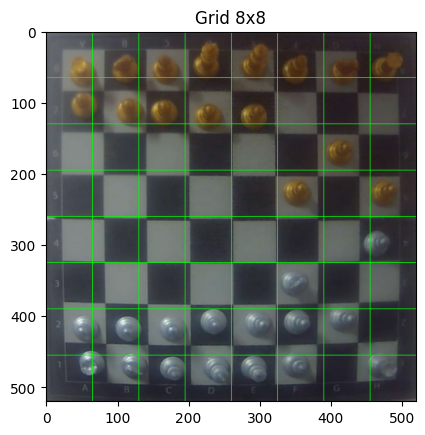

In [34]:
sq_size = side // 8
squares_centers = []

warped_grid = warped.copy()

for row in range(8):
    for col in range(8):
        # Tọa độ pixel của từng ô để vẽ hoặc cắt ảnh nhận diện quân cờ
        x1, y1 = col * sq_size, row * sq_size
        x2, y2 = (col + 1) * sq_size, (row + 1) * sq_size

        # Vẽ lưới lên ảnh warped để kiểm tra
        cv2.rectangle(warped_grid, (x1, y1), (x2, y2), (0, 255, 0), 1)

        # Lưu tâm của ô để xử lý logic sau này
        squares_centers.append((x1 + sq_size//2, y1 + sq_size//2))

print(warped_grid.shape)

plt.imshow(cv2.cvtColor(warped_grid, cv2.COLOR_BGR2RGB))
plt.title("Grid 8x8")
plt.show()

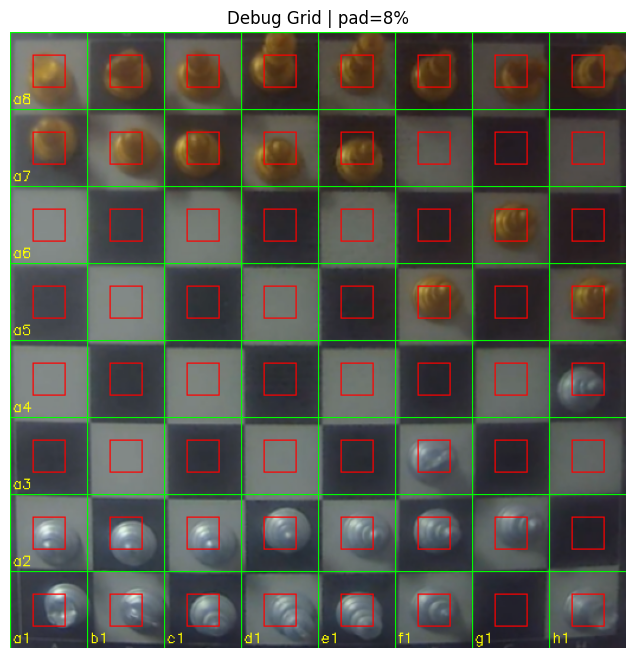

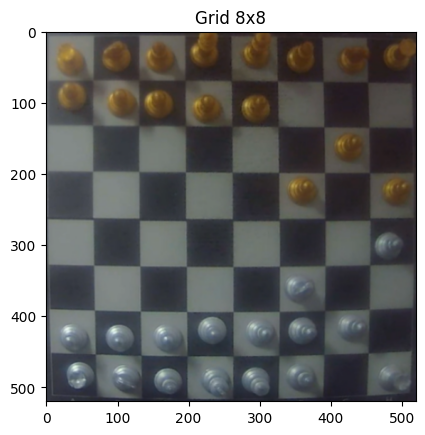

In [35]:
def inner_wrap(
        warped_img,
        warped_size=WRAP_SIZE,
        pad_percent=8,
        cell_margin_percent=0.3,
        debug=False
    ):
    """
    Chuẩn hóa bàn cờ sau khi warp perspective.

    Args:
        warped_img: ảnh warp từ perspective transform
        warped_size: kích thước bàn cờ output
        pad_percent: phần trăm cắt viền
        cell_margin_percent: margin vùng trung tâm ô
        debug: hiển thị grid debug

    Returns:
        current_warped_img
    """

    # =============================
    # 1. Crop border
    # =============================
    pad = int(warped_size * (pad_percent / 100.0) / 2)

    inner = warped_img[
        pad:warped_size-pad,
        pad:warped_size-pad
    ]

    inner = cv2.resize(inner, (warped_size, warped_size))
    current_warped_img = inner

    # =============================
    # 2. Debug grid
    # =============================
    if debug:

        debug_view = inner.copy()

        sq_size = warped_size // 8
        cell_pad = int(sq_size * cell_margin_percent)

        for row in range(8):
            for col in range(8):

                x1 = col * sq_size
                y1 = row * sq_size
                x2 = (col + 1) * sq_size
                y2 = (row + 1) * sq_size

                # Grid ô cờ
                cv2.rectangle(debug_view, (x1,y1), (x2,y2), (0,255,0), 1)

                # Vùng trung tâm ô
                ix1 = x1 + cell_pad
                iy1 = y1 + cell_pad
                ix2 = x2 - cell_pad
                iy2 = y2 - cell_pad

                cv2.rectangle(debug_view, (ix1,iy1), (ix2,iy2), (0,0,255), 1)

                # Label a8-h1
                if col == 0 or row == 7:
                    label = f"{chr(97+col)}{8-row}"
                    cv2.putText(
                        debug_view,
                        label,
                        (x1+2, y2-5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.4,
                        (0,255,255),
                        1
                    )

        plt.figure(figsize=(8,8))
        plt.imshow(cv2.cvtColor(debug_view, cv2.COLOR_BGR2RGB))
        plt.title(f"Debug Grid | pad={pad_percent}%")
        plt.axis("off")
        plt.show()

    return current_warped_img
current_warped_img = inner_wrap(warped, debug=True, pad_percent=8)
plt.imshow(cv2.cvtColor(current_warped_img, cv2.COLOR_BGR2RGB))
plt.title("Grid 8x8")
plt.show()

In [36]:
def inner_wrap(
        warped_img,
        warped_size=WRAP_SIZE,
        pad_percent=8,
        cell_margin_percent=0.3,
        debug=False
    ):

    pad = int(warped_size * (pad_percent / 100.0) / 2)

    inner = warped_img[
        pad:warped_size-pad,
        pad:warped_size-pad
    ]

    inner = cv2.resize(inner, (warped_size, warped_size))
    current_warped_img = inner

    # 4 corner của inner trong hệ tọa độ warped_img
    corners = np.array([
        [pad, pad],
        [warped_size-pad, pad],
        [warped_size-pad, warped_size-pad],
        [pad, warped_size-pad]
    ], dtype=np.int32)

    print("Inner corners in warped image:")
    for i, (x,y) in enumerate(corners):
        print(f"corner {i}: ({x},{y})")

    if debug:

        debug_view = warped_img.copy()

        for (x,y) in corners:
            cv2.circle(debug_view,(x,y),8,(0,0,255),-1)

        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(debug_view, cv2.COLOR_BGR2RGB))
        plt.title("Inner corners on warped image")
        plt.axis("off")
        plt.show()

    return current_warped_img, corners

Inner corners in warped image:
corner 0: (20,20)
corner 1: (500,20)
corner 2: (500,500)
corner 3: (20,500)


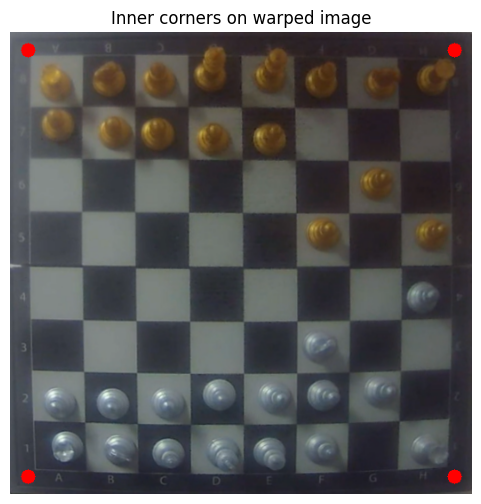

In [37]:
current_warped_img, corners = inner_wrap(
    warped,
    debug=True,
    pad_percent=8
)

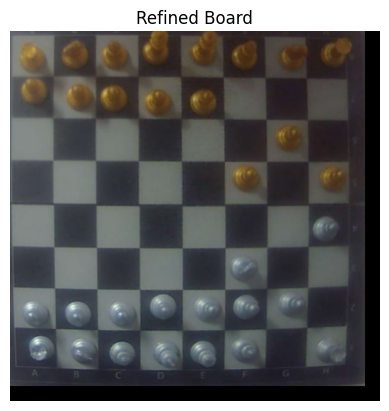

In [38]:
pts_src = corners.astype("float32")

pts_dst = np.array([
    [0,0],
    [479,0],
    [479,479],
    [0,479]
], dtype="float32")

M = cv2.getPerspectiveTransform(pts_src, pts_dst)

refined_board = cv2.warpPerspective(warped, M, (WRAP_SIZE, WRAP_SIZE))
plt.imshow(cv2.cvtColor(refined_board, cv2.COLOR_BGR2RGB))
plt.title("Refined Board")
plt.axis("off")
plt.show()

## Manual inner

### Chọn 4 điểm bằng chuột

In [39]:
clicked_points = []

def mouse_click(event, x, y, flags, param):
    global clicked_points

    if event == cv2.EVENT_LBUTTONDOWN:
        clicked_points.append((x, y))
        print("Point:", x, y)

        cv2.circle(param, (x, y), 6, (0,0,255), -1)
        cv2.imshow("select corners", param)

In [40]:
def select_board_corners(img):
    global clicked_points
    clicked_points = []
    clone = img.copy()
    cv2.imshow("select corners", clone)
    cv2.setMouseCallback("select corners", mouse_click, clone)
    print("Click 4 corners of board (TL → TR → BR → BL)")
    while True:
        cv2.imshow("select corners", clone)
        if len(clicked_points) == 4:
            break
        if cv2.waitKey(1) & 0xFF == 27:
            break
    cv2.destroyAllWindows()
    return np.array(clicked_points, dtype="float32")

### Wrap lại theo góc chuột

In [41]:
def manual_rewarp(img, pts_src, size=WRAP_SIZE):

    pts_dst = np.array([
        [0,0],
        [size-1,0],
        [size-1,size-1],
        [0,size-1]
    ], dtype="float32")
    M = cv2.getPerspectiveTransform(pts_src, pts_dst)
    warped = cv2.warpPerspective(img, M, (size, size))
    return warped

Click 4 corners of board (TL → TR → BR → BL)
Point: 22 27
Point: 496 31
Point: 494 490
Point: 28 493


(np.float64(-0.5), np.float64(519.5), np.float64(519.5), np.float64(-0.5))

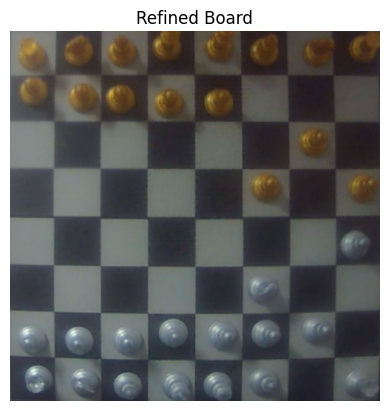

In [42]:
# chọn góc bằng chuột
pts = select_board_corners(warped)

# warp lại chính xác
warped_refined = manual_rewarp(warped, pts)

plt.imshow(cv2.cvtColor(warped_refined, cv2.COLOR_BGR2RGB))
plt.title("Refined Board")
plt.axis("off")

In [43]:
# !pip install python-chess

In [44]:
import chess
import chess.pgn

# Khởi tạo bàn cờ logic
board = chess.Board()
game = chess.pgn.Game()
node = game # Để tracking các nước đi tiếp theo

# Ví dụ: Giả sử bạn nhận diện được nước đi từ e2 đến e4 (sử dụng tọa độ ô)
# move = chess.Move.from_uci("e2e4")
# if move in board.legal_moves:
#     board.push(move)
#     node = node.add_main_variation(move)

# Xuất chuỗi PGN (như trong file test_chess_thaihung2.py)
exporter = chess.pgn.StringExporter(headers=True, variations=True, comments=True)
pgn_string = game.accept(exporter)
print("Chuỗi PGN hiện tại:")
print(pgn_string)

Chuỗi PGN hiện tại:
[Event "?"]
[Site "?"]
[Date "????.??.??"]
[Round "?"]
[White "?"]
[Black "?"]
[Result "*"]

*
